# Nhận Dạng Ký Tự Sử Dụng Naïve Bayes
Dataset: UCI Letter Recognition  
- 26 lớp (A-Z)  
- 16 đặc trưng (vector 16-D)  
- 20.000 mẫu  
Tham khảo: https://archive.ics.uci.edu/dataset/59/letter+recognition  

Trong notebook này, chúng ta sẽ:  
1. Tải dataset.  
2. Khám phá dữ liệu.  
3. Chuẩn bị dữ liệu (split train/test).  
4. Huấn luyện mô hình Naïve Bayes.  
5. Đánh giá mô hình.  

## Import Thư Viện

In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Tải Dataset
Sử dụng ucimlrepo để fetch dataset Letter Recognition (ID=59).  
- X: Đặc trưng (features).  
- y: Nhãn (targets, lớp A-Z).  

In [2]:
# Fetch dataset
letter_recognition = fetch_ucirepo(id=59)

# Data (as pandas dataframes)
X = letter_recognition.data.features
y = letter_recognition.data.targets

# Metadata
print(letter_recognition.metadata)

# Variable information
print(letter_recognition.variables)

# Kiểm tra shape
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

{'uci_id': 59, 'name': 'Letter Recognition', 'repository_url': 'https://archive.ics.uci.edu/dataset/59/letter+recognition', 'data_url': 'https://archive.ics.uci.edu/static/public/59/data.csv', 'abstract': 'Database of character image features; try to identify the letter', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 20000, 'num_features': 16, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['lettr'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1991, 'last_updated': 'Thu Sep 28 2023', 'dataset_doi': '10.24432/C5ZP40', 'creators': ['David Slate'], 'intro_paper': None, 'additional_info': {'summary': 'The objective is to identify each of a large number of black-and-white rectangular pixel displays as one of the 26 capital letters in the English alphabet.  The character images were based on 20 different fonts and each letter within these 20 fonts wa

## Khám Phá Dữ Liệu
- Xem mẫu dữ liệu.  
- Kiểm tra missing values.  
- Phân bố nhãn.  
- Thống kê mô tả đặc trưng.  

First 5 rows of X:
   x-box  y-box  width  high  onpix  x-bar  y-bar  x2bar  y2bar  xybar  x2ybr  \
0      2      8      3     5      1      8     13      0      6      6     10   
1      5     12      3     7      2     10      5      5      4     13      3   
2      4     11      6     8      6     10      6      2      6     10      3   
3      7     11      6     6      3      5      9      4      6      4      4   
4      2      1      3     1      1      8      6      6      6      6      5   

   xy2br  x-ege  xegvy  y-ege  yegvx  
0      8      0      8      0      8  
1      9      2      8      4     10  
2      7      3      7      3      9  
3     10      6     10      2      8  
4      9      1      7      5     10  

First 5 rows of y:
  lettr
0     T
1     I
2     D
3     N
4     G

Missing values in X: 0
Missing values in y: 0


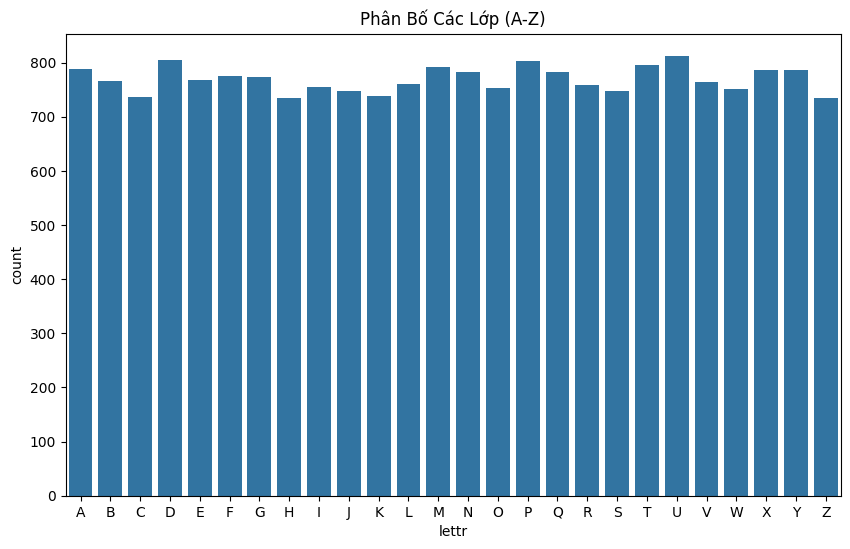


Descriptive statistics of X:
              x-box         y-box         width         high         onpix  \
count  20000.000000  20000.000000  20000.000000  20000.00000  20000.000000   
mean       4.023550      7.035500      5.121850      5.37245      3.505850   
std        1.913212      3.304555      2.014573      2.26139      2.190458   
min        0.000000      0.000000      0.000000      0.00000      0.000000   
25%        3.000000      5.000000      4.000000      4.00000      2.000000   
50%        4.000000      7.000000      5.000000      6.00000      3.000000   
75%        5.000000      9.000000      6.000000      7.00000      5.000000   
max       15.000000     15.000000     15.000000     15.00000     15.000000   

              x-bar         y-bar         x2bar         y2bar         xybar  \
count  20000.000000  20000.000000  20000.000000  20000.000000  20000.000000   
mean       6.897600      7.500450      4.628600      5.178650      8.282050   
std        2.026035      2.325

In [3]:
# Xem 5 dòng đầu
print("First 5 rows of X:")
print(X.head())

print("\nFirst 5 rows of y:")
print(y.head())

# Kiểm tra missing values
print("\nMissing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum().sum())

# Phân bố nhãn (A-Z)
plt.figure(figsize=(10,6))
sns.countplot(x='lettr', data=y, order=sorted(y['lettr'].unique()))
plt.title('Phân Bố Các Lớp (A-Z)')
plt.show()

# Thống kê mô tả cho X
print("\nDescriptive statistics of X:")
print(X.describe())

## Chuẩn Bị Dữ Liệu
- Split dataset thành train (80%) và test (20%).  
- y cần flatten để phù hợp với sklearn.  

In [4]:
# Flatten y thành array 1D
y = y.values.ravel()

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape: X {X_train.shape}, y {y_train.shape}")
print(f"Test shape: X {X_test.shape}, y {y_test.shape}")

Train shape: X (16000, 16), y (16000,)
Test shape: X (4000, 16), y (4000,)


## Huấn Luyện Mô Hình
Sử dụng Gaussian Naïve Bayes (phù hợp với đặc trưng số liên tục/thống kê).  

In [5]:
# Khởi tạo mô hình
model = GaussianNB()

# Huấn luyện
model.fit(X_train, y_train)

print("Huấn luyện hoàn tất.")

Huấn luyện hoàn tất.


## Đánh Giá Mô Hình
- Dự đoán trên test set.  
- Tính accuracy, classification report.  
- Vẽ confusion matrix.  

Accuracy: 65.22%

Classification Report:
              precision    recall  f1-score   support

           A       0.85      0.87      0.86       158
           B       0.48      0.72      0.57       153
           C       0.80      0.82      0.81       147
           D       0.61      0.71      0.66       161
           E       0.61      0.38      0.47       154
           F       0.70      0.77      0.73       155
           G       0.59      0.55      0.57       155
           H       0.58      0.35      0.44       147
           I       0.52      0.71      0.60       151
           J       0.83      0.71      0.77       149
           K       0.49      0.49      0.49       148
           L       0.91      0.78      0.84       152
           M       0.69      0.88      0.77       158
           N       0.89      0.68      0.77       157
           O       0.48      0.74      0.58       150
           P       0.87      0.78      0.82       161
           Q       0.53      0.51      0

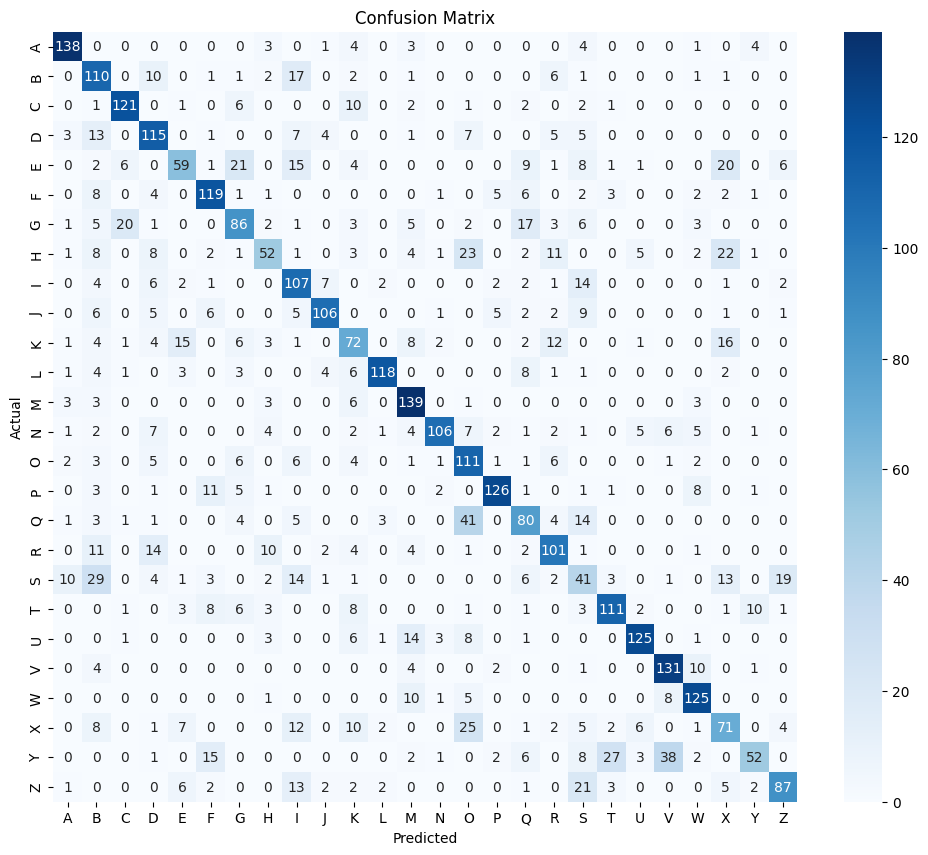

In [6]:
# Dự đoán
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(set(y_test)), yticklabels=sorted(set(y_test)))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Kết Luận
- Mô hình Naïve Bayes đạt accuracy khoảng 65.22%.  
- Cải tiến: Thử MultinomialNB, thêm feature engineering, hoặc dùng cross-validation.  
- Tham khảo thêm: Tài liệu sklearn về Naïve Bayes.  